# Going Causal - Comparing with Rrs-based Models
## I. Preamble
### Study Plan: TOA Radiance vs Rrs for Phytoplankton Absorption Retrieval

#### Objective
Evaluate whether **skipping atmospheric correction (Rrc)** yields predictive performance for phytoplankton absorption (`aph_443`, `aph_555`, `aph_670`) that is **comparable to or better than** using **atmospherically corrected reflectance (Rrs)**—especially in **coastal** environments where optical complexity may degrade Rrs-based inference.

#### Key Design Principles
- **Treatments are separate:**  
  - *Treatment A:* Only Fresnel and Raleigh-correction applied → predictors = `log10(Rrc)`  
  - *Treatment B:* Full atmospheric correction applied → predictors = `log10(Rrs)`  

- **Region partial pooling within each treatment:**  
  - Region ∈ {coastal (proxy is $\lt$ 200 m depth), offshore $\ge$ 200m depth }.  
  - Allow region-varying intercepts (and optionally slopes) **within a treatment** to stabilize estimates and test coastal dependence.
  - This helps determining the magnitude of optical complexity impact, if any.
  - Note that this is a first order proxy for optical complexity. More sophisticated coastal flags can be used in its stead.

#### Data
- **Paired subset (n = 148)** where both `Rrc` and `Rrs` are available for the same observation(s).  
- Responses: `log10(aph_443)`, `log10(aph_555)`, `log10(aph_670)`  
- Predictors: log-transformed spectral inputs (TOA radiance or Rrs bands, matched to `aph` wavelengths per model).  
- Covariate: `region` (binary: coastal/offshore), derived via our coastal classifier.

#### Models

##### Baseline per-treatment model (independent bands)
For each treatment T ∈ {Rrc, Rrs} and band λ:
- Likelihood:  
  `log10(aph_λ,i) ~ Normal(μ_λ,i, σ_λ)`
- Mean structure with region effects:  
  `μ_λ,i = α_{λ,region[i]}^T + β_{λ,region[i]}^T · log10(X_i^T)`  
  with partial pooling over `region` **within** treatment T:
  - `α_{λ,region} ~ Normal(α_{λ,μ}, σ_{α,λ})`
  - `β_{λ,region} ~ Normal(β_{λ,μ}, Σ_{β,λ})`
- Identical prior families/scales across treatments, but **parameters are not shared**.

##### Optional upgrade (per treatment): MVN / Matrix-Normal
- If residuals show cross-band correlation or joint inference across (443, 555, 670) is required:
  - Replace independent-band likelihood with **MVN over bands** (treatment-specific covariance `Σ_y,T`).

#### Preprocessing & Priors
- Standardize predictors **within treatment** to align priors and stabilize sampling.  
- Prior scales (log–log setting): moderately informative (e.g., slopes `Normal(0, 0.5)`; intercepts centered with domain-informed spread).  
- Use Student-t errors if heavy tails are suspected, else Normal.

#### Evaluation Strategy (paired & stratified)
1. **PSIS-LOO (stratified by region):**  
   - Compute ELPD for Rrc-model and Rrs-model **within coastal** and **within offshore** strata.  
   - Report ΔELPD_coastal and ΔELPD_offshore with SE/HDI.

2. **Paired per-observation scores:**  
   - Using the pairing (same `aph` target, two predictor sets), compute per-observation posterior of  
     `Δ_i = log-score_Rrc(i) − log-score_Rrs(i)` (and/or CRPS, absolute error).  
   - Summarize Δ by region: mean, HDI, and `P(Δ > 0)`.

3. **Calibration & Coverage (by treatment × region):**  
   - LOO-PIT ECDF vs uniform with envelopes; check deviations (under/overconfidence).  
   - Predictive coverage at 50/80/94% intervals; compare observed vs nominal.

4. **Posterior contrasts (region effects):**  
   - Within each treatment, examine `β_{λ,coastal} − β_{λ,offshore}` to quantify coastal dependence.

#### Diagnostics
- Convergence: R-hat, ESS (bulk/tail), BFMI, energy plots.  
- PSIS k-hat checks; apply reloo if needed.  
- Residual checks and PPCs by region and treatment.

#### Sensitivity Analyses
- Swap Normal vs Student-t likelihood.  
- Add/removal of region-varying slopes (keep if supported).  
- MVN vs independent-band likelihood (report effect on calibration/coverage).  
- Alternative coastal classification thresholds (robustness).

#### Reporting
- **Headline:** ΔELPD_coastal and ΔELPD_offshore comparing Rrc vs Rrs.  
- **Calibration/coverage** panels stratified by region × treatment.  
- **Paired Δ-score distributions** (bean/violin or HDI intervals) by region.  
- **Coefficient summaries** for region effects within treatment (with interpretation).  
- Emphasize that **treatments are fit independently** (no cross-talk), with identical structures and priors → fair comparison.  
- If MVN used, note improved joint calibration across bands without altering the qualitative treatment contrast.

#### Decision Rule (interpretation)
- If ΔELPD_coastal ≫ 0 (Rrc better) and calibration/coverage favor Rrc in coastal waters → evidence that **skipping AC is advantageous** in coastal settings.  
- If offshore results are parity (ΔELPD_offshore ≈ 0) and both are well-calibrated → **no penalty offshore** for using Rrc.  
- If Rrs outperforms Rrc offshore but not coastally, report the trade-off and contextual guidance.

## II. Notebook Prep

In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
from pathlib import Path

import pandas as pd
import numpy as np
import xarray as xr


from sklearn.preprocessing import StandardScaler
import pymc as pm

# ---------- PLOTTING ----------

import matplotlib as mpl
import matplotlib.pyplot as pp
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import arviz as az
import seaborn as sb

# ---------- HOMEGROWN ----------

from scripts.model_utils import save_idata, load_idata
from scripts.model_utils import find_influential_observations, posterior_coverage

from scripts.pnas_utils import facet_height_for_pnas, set_pnas_style, fig_ax, save_pnas, pnas_figure, OKABE_ITO
from scripts.plot_utils import plot_regression_hdi, plot_3_way_ppc, plot_ppc_hdi_band_multi
from scripts.plot_utils import plot_ppc_pit_grid, compare_ppc, plot_ppc_pit, save_model_dag

In [3]:
print('Package Versions: ', end='\n' + 50*'--' + '\n')
print(f'PyMC - {pm.__version__}')
print(f'PanDaS - {pd.__version__}')
print(f'Arviz - {az.__version__}')
print(f'Seaborn - {sb.__version__}')

Package Versions: 
----------------------------------------------------------------------------------------------------
PyMC - 5.20.1
PanDaS - 2.2.3
Arviz - 0.21.0
Seaborn - 0.13.2


In [4]:
ROOT = Path(".").resolve()
DIR = {
    "data": ROOT / "data/03_transformed",
    "idata": ROOT / "inferencedata",
    "figs": ROOT / "figs",
    "results": ROOT / "results",
}
for d in DIR.values():
    d.mkdir(parents=True, exist_ok=True)

set_pnas_style(base_font_size=9)

In [24]:
# SOME CONFIGS 

# Common constants
APH_BANDS = [443, 555, 670]
INPUT_BANDS = [412, 443, 490, 510, 555, 670] # Rrs and Rrc
# Map friendly names → file tags (tag.nc)
MODEL_TAGS = {
    "Causal Linear (diag cov)":      "causal_linear_diag",
    "Causal Hier-Linear (diag cov)": "causal_hier_lin_diag",
    "Causal Linear (full Σ)":        "causal_linear_mvn"
}

PNAS_WIDTH_IN = {"one": 3.43, "two": 7.00}
# Colorblind-safe mapping (Okabe–Ito)
BAND_COLORS = {
    443:  "#000000",  # blue
    555:  "#E69F00",  # green
    670:  "#56B4E9" ,  # vermillion
}
PPC_COLORS: list[str]= ['darkgray', 'k', 'C1']

legend_handles = [
    Line2D([0], [0], color=BAND_COLORS[443], lw=1.2, label="443 nm"),
    Line2D([0], [0], color=BAND_COLORS[555], lw=1.2, label="555 nm"),
    Line2D([0], [0], color=BAND_COLORS[670], lw=1.2, label="670 nm"),
]

## II. Data Loading and Standardization 

### 1. Data Loading
The data was previously log-transformed and merged (see preprocessing notebook) before being saved as parquet and csv files. 


In [8]:
df_aiop = pd.read_parquet(DIR['data'] / 'df_log_rrc_rrs_aph.pqt')
df_env = pd.read_parquet(DIR['data'] / 'df_env.pqt')

In [ ]:
df_merged = pd.merge(df_aiop, df_env, right_index=True, left_index=True)

In [13]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 2 to 494
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   log_rrc_412        148 non-null    float64 
 1   log_rrc_443        148 non-null    float64 
 2   log_rrc_490        148 non-null    float64 
 3   log_rrc_510        148 non-null    float64 
 4   log_rrc_555        148 non-null    float64 
 5   log_rrc_670        148 non-null    float64 
 6   log_rrs412         148 non-null    float64 
 7   log_rrs443         148 non-null    float64 
 8   log_rrs490         148 non-null    float64 
 9   log_rrs510         148 non-null    float64 
 10  log_rrs555         148 non-null    float64 
 11  log_rrs670         148 non-null    float64 
 12  log_aph443         148 non-null    float64 
 13  log_aph555         148 non-null    float64 
 14  log_aph670         148 non-null    float64 
 15  lat                148 non-null    float64 
 16  lon          

In [12]:
df_merged.head().T

index,2,3,26,31,32
log_rrc_412,-2.352334,-2.231428,-1.92352,-2.249286,-2.149054
log_rrc_443,-2.357865,-2.231674,-1.979738,-2.186108,-2.11277
log_rrc_490,-2.372588,-2.256908,-2.130938,-2.140208,-2.059395
log_rrc_510,-2.433492,-2.333192,-2.317377,-2.109954,-2.031909
log_rrc_555,-2.577377,-2.478052,-2.50805,-2.036746,-1.952846
log_rrc_670,-2.929113,-2.757732,-2.764143,-2.243432,-2.251107
log_rrs412,-2.366532,-2.314258,-1.839231,-3.420216,-2.640165
log_rrs443,-2.41005,-2.340084,-1.939302,-2.779892,-2.498941
log_rrs490,-2.444906,-2.377786,-2.170696,-2.546682,-2.340084
log_rrs510,-2.554396,-2.5157,-2.464706,-2.454693,-2.274088


Only log_rrs and log_rrc will be standardized. They will be standardized independently. Note that the scaler object will be saved so as to retain the mean and standard deviation applied for scaling the data for reverting to the original scale in this notebook (e.g. for plotting purposes, when useful) or to re-do the scaling elsewhere.


In [16]:
x_log_rrc = df_merged.filter(like='log_rrc')
x_log_rrs = df_merged.filter(like='log_rrs')
y_log_aph = df_merged.filter(like='aph')
shelf_flag = df_merged.is_shelf_200m

### 2. Standardization

In [17]:
rrs_scaler = StandardScaler(with_mean=True, with_std=True).fit(x_log_rrs)
rrc_scaler = StandardScaler(with_mean=True, with_std=True).fit(x_log_rrc)

In [18]:
z_rrs = rrs_scaler.transform(x_log_rrs)
z_rrc = rrc_scaler.transform(x_log_rrc)

## III. Modeling

### Approach: Global Intercept + Zero-Sum Environment Offsets (Per Treatment)

#### Goal
Estimate treatment-specific linear relationships from spectral predictors to `log10(aph)` while allowing a **coastal vs offshore** shift, without introducing weakly identified intercepts that cause HMC divergences.

#### Key Idea
For each treatment (Rrc and Rrs, fit **separately**), write the mean as:
$$
\mu_{i,\lambda} \;=\; \underbrace{\alpha_{0,\lambda}}_{\text{global intercept}}
\;+\; \underbrace{\delta_{\text{env}(i),\lambda}}_{\text{env offset, zero-sum}}
\;+\; \mathbf{z}_{i}^{\top}\boldsymbol{\beta}_{\lambda}
$$
- $\alpha_{0,\lambda}$: band-specific global intercept.
- $\delta_{\text{env},\lambda}$: band-specific **environment offset** constrained to **sum to zero** across env levels \(\{\text{offshore}, \text{coastal}\}\).
- $\mathbf{z}_i$: standardized inputs (six bands), standardized **within treatment**.
- $\boldsymbol{\beta}_\lambda$: band-specific slope vector (shared across env).

#### Zero-Sum Constraint
We place a **Zero-Sum Normal** prior on the env offsets:
$$
\boldsymbol{\delta}_{\lambda} = (\delta_{\text{off},\lambda},\;\delta_{\text{coast},\lambda})^{\top}
\quad\text{with}\quad
\delta_{\text{off},\lambda}+\delta_{\text{coast},\lambda}=0,\qquad
\boldsymbol{\delta}_{\lambda}\sim \mathcal{ZS}\mathcal{N}(0,\sigma_\delta^2).
$$
This parameterization creates a **pure contrast** around the global level, removing the redundant location in the env layer and eliminating the funnel that causes divergences.

#### Why This Works (and Why It’s Minimal)
- **Identifiability:** The global location lives in \(\alpha_{0,\lambda}\); env differences live in a **contrast** with sum-to-zero → no tug-of-war between two free intercepts.
- **Stability for HMC:** The geometry is better conditioned; empirically reduces/dives to zero the NUTS divergences introduced by naive two-intercept coding.
- **Interpretability:** \(\delta_{\text{coast},\lambda} = -\delta_{\text{off},\lambda}\) is a centered shift; the **coastal-minus-offshore** effect is simply \(2\delta_{\text{coast},\lambda}\).
- **No cross-talk:** Treatments are fit in **separate models** with identical structure/priors; comparisons are made via paired utilities (ΔELPD/ΔCRPS) and calibration by region.

#### Practical Notes
- Keep \(\mathbf{z}\) standardized per treatment; do **not** standardize per region.
- Use modestly regularizing priors: \(\beta \sim \mathcal{N}(0, 0.3\text{–}0.5)\), \(\sigma_\delta \approx 0.3\text{–}0.5\), \(\sigma_y \sim \text{HalfNormal}(0.5)\).
- If needed, raise `target_accept` slightly (e.g., 0.92–0.95); this is typically sufficient with the zero-sum reparameterization.




### 1. Prep step


In [37]:

λ_in =   [str(ib) for ib in INPUT_BANDS]
λ_aph =   [str(ab) for ab in APH_BANDS]
is_shelf_idx, is_shelf = shelf_flag.factorize()
coords_causal = {
    'obs_idx': df_merged.index,
    'λ_in': λ_in,
    'λ_aφ' : λ_aph,
    'env': ['coastal' if li else 'offshore' for li in is_shelf]
}


### 2. Model Definitions
#### a) "Linear (diag cov)"


In [120]:
with pm.Model(coords=coords_causal) as mlin_rrs:
    zX   = pm.Data("z_log_rrs", z_rrs, dims=("obs_idx","λ_in"))
    Y    = pm.Data("log_aph",   y_log_aph, dims=("obs_idx","λ_aφ"))
    envI = pm.Data("env_idx",   is_shelf_idx.astype(int), dims=("obs_idx",))  # 0=offshore, 1=coastal

    # Global intercept per aph band
    α0 = pm.Normal("α0", 0, 1, dims=("λ_aφ",))                 # (3,)

    # Zero-sum env offsets per band: shape (env=2, band=3), sums to zero over env
    δ_env = pm.ZeroSumNormal("δ_env", sigma=0.5, dims=("env","λ_aφ"))
    # pick the offset for each obs env
    δ_pick = δ_env[envI, :]                                    # (n,3)

    β = pm.Normal("β", 0, 0.5, dims=("λ_in","λ_aφ"))           # (6,3)
    μ = pm.Deterministic("μ", α0 + δ_pick + zX @ β, dims=("obs_idx","λ_aφ"))

    σ = pm.HalfNormal("σ", 0.5, dims=("λ_aφ",))
    pm.Normal("y", mu=μ, sigma=σ, observed=Y, dims=("obs_idx","λ_aφ"))

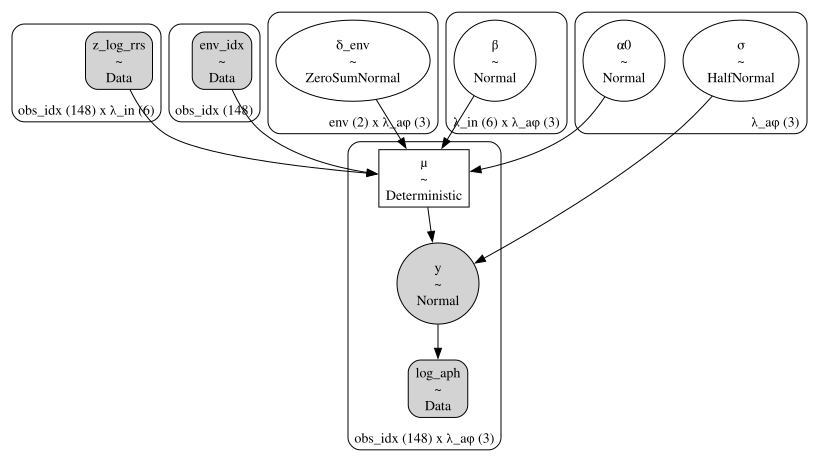

In [121]:
mlin_rrs.to_graphviz()

In [122]:
with pm.Model(coords=coords_causal) as mlin_rrc:
    zX   = pm.Data("z_log_rrc", z_rrc, dims=("obs_idx","λ_in"))
    Y    = pm.Data("log_aph",   y_log_aph, dims=("obs_idx","λ_aφ"))
    envI = pm.Data("env_idx",   is_shelf_idx.astype(int), dims=("obs_idx",))  # 0=offshore, 1=coastal

    # Global intercept per aph band
    α0 = pm.Normal("α0", 0, 1, dims=("λ_aφ",))                 # (3,)

    # Zero-sum env offsets per band: shape (env=2, band=3), sums to zero over env
    δ_env = pm.ZeroSumNormal("δ_env", sigma=0.5, dims=("env","λ_aφ"))
    # pick the offset for each obs env
    δ_pick = δ_env[envI, :]                                    # (n,3)

    β = pm.Normal("β", 0, 0.5, dims=("λ_in","λ_aφ"))           # (6,3)
    μ = pm.Deterministic("μ", α0 + δ_pick + zX @ β, dims=("obs_idx","λ_aφ"))

    σ = pm.HalfNormal("σ", 0.5, dims=("λ_aφ",))
    pm.Normal("y", mu=μ, sigma=σ, observed=Y, dims=("obs_idx","λ_aφ"))



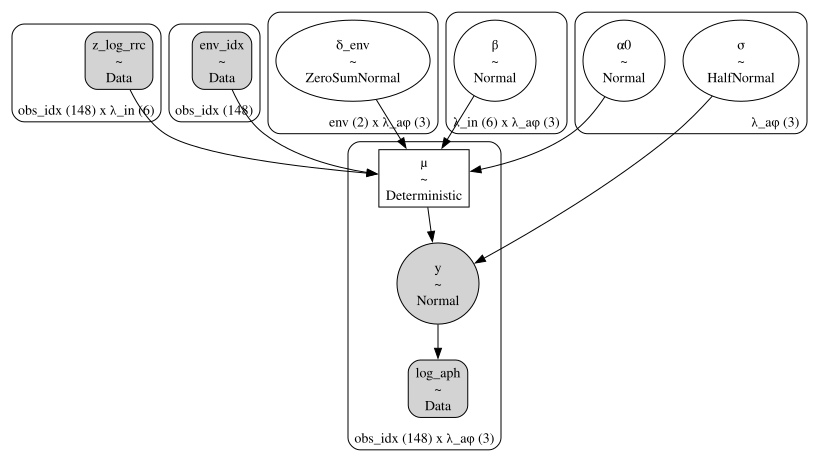

In [123]:
mlin_rrc.to_graphviz()

#### b) "Hier-Linear (diag cov)"

#### c) "Linear (full Σ)"

### 3. Prior Predictive Checks

In [124]:
with mlin_rrs:
    idata_lin_rrs = pm.sample_prior_predictive()

Sampling: [y, α0, β, δ_env, σ]


In [125]:
with mlin_rrc:
    idata_lin_rrc = pm.sample_prior_predictive()

Sampling: [y, α0, β, δ_env, σ]


Text(0.5, 0.98, 'Prior Predictive Check')

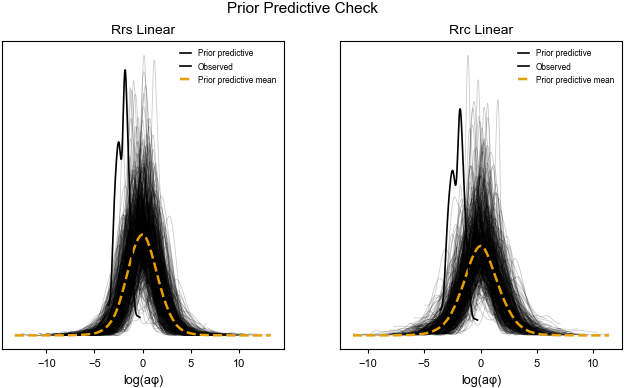

In [126]:
f, axs = pp.subplots(ncols=2, figsize=(8, 4))
az.plot_ppc(idata_lin_rrs, group='prior', observed=True, ax=axs[0])
az.plot_ppc(idata_lin_rrc, group='prior', observed=True, ax=axs[1])
axs[0].set_xlabel('log(aφ)')
axs[1].set_xlabel('log(aφ)')
axs[0].set_title('Rrs Linear')
axs[1].set_title('Rrc Linear')
f.suptitle('Prior Predictive Check')

### 3. Posterior Sampling & Sampling Diagnostics

In [127]:
with mlin_rrs:
    idata_lin_rrs.extend(pm.sample(draws=2000, chains=4))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α0, δ_env, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 22 seconds.


In [128]:
az.summary(idata_lin_rrs, kind='diagnostics') 

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α0[443],0.003,0.003,6642.0,5516.0,1.0
α0[555],0.004,0.003,6097.0,5347.0,1.0
α0[670],0.003,0.003,6527.0,5630.0,1.0
"β[412, 443]",0.001,0.001,9059.0,6271.0,1.0
"β[412, 555]",0.001,0.001,9314.0,6037.0,1.0
...,...,...,...,...,...
"μ[492, 555]",0.001,0.001,8785.0,7046.0,1.0
"μ[492, 670]",0.001,0.001,8310.0,7405.0,1.0
"μ[494, 443]",0.000,0.000,8736.0,7077.0,1.0
"μ[494, 555]",0.000,0.000,8324.0,7587.0,1.0


<Axes: >

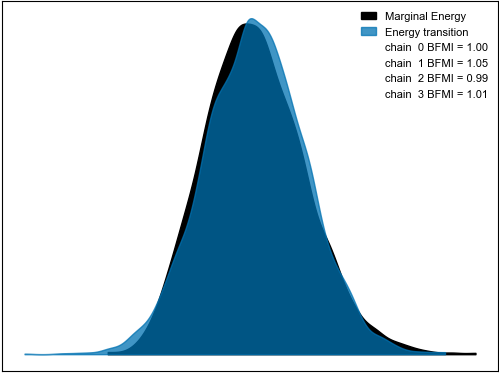

In [129]:
az.plot_energy(idata_lin_rrs)

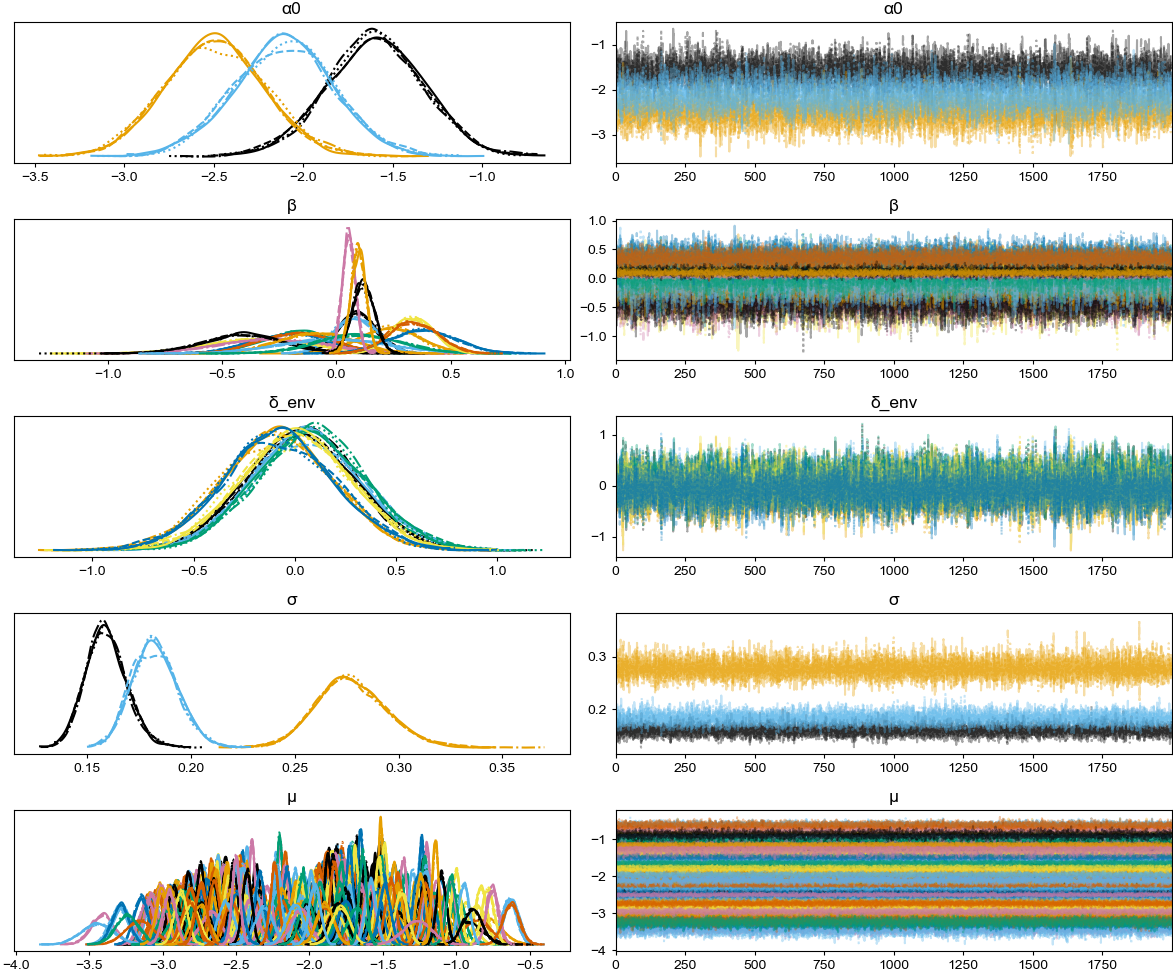

In [136]:
axs = az.plot_trace(idata_lin_rrs)
f = pp.gcf()
f.tight_layout()

In [131]:
with mlin_rrc:
    idata_lin_rrc.extend(pm.sample(draws=2000, chains=4))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α0, δ_env, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


In [132]:
az.summary(idata_lin_rrc)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α0[443],-1.595,0.273,-2.110,-1.087,0.004,0.003,4351.0,5319.0,1.0
α0[555],-2.482,0.275,-2.979,-1.945,0.004,0.003,4936.0,5303.0,1.0
α0[670],-2.117,0.275,-2.603,-1.590,0.004,0.003,4782.0,4887.0,1.0
"β[412, 443]",0.577,0.196,0.209,0.943,0.002,0.002,9261.0,6172.0,1.0
"β[412, 555]",0.333,0.246,-0.131,0.797,0.002,0.003,10470.0,6395.0,1.0
...,...,...,...,...,...,...,...,...,...
"μ[492, 555]",-1.900,0.066,-2.018,-1.768,0.001,0.001,8719.0,6289.0,1.0
"μ[492, 670]",-1.488,0.051,-1.587,-1.396,0.001,0.001,8261.0,6345.0,1.0
"μ[494, 443]",-1.133,0.027,-1.181,-1.081,0.000,0.000,7851.0,7078.0,1.0
"μ[494, 555]",-2.011,0.043,-2.088,-1.925,0.000,0.000,7652.0,7244.0,1.0


<Axes: >

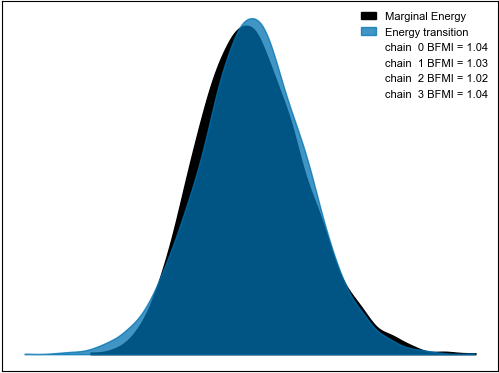

In [134]:
az.plot_energy(idata_lin_rrc)

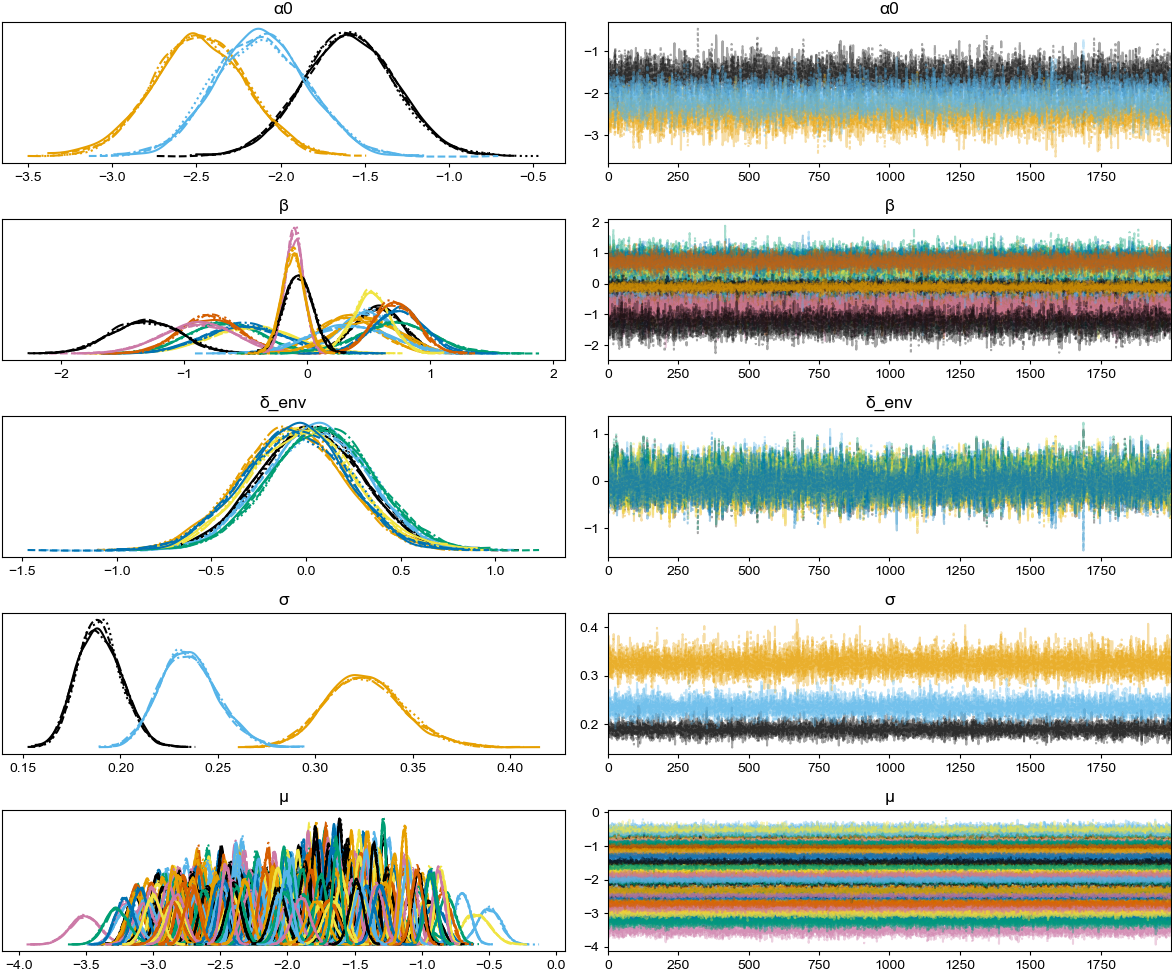

In [137]:
axs = az.plot_trace(idata_lin_rrc)
f = pp.gcf()
f.tight_layout()

### 4. Posterior Predictive Checks & Uncertainty Calibration Assessment

### 5. Model Comparison 

### 6. Causal Assessment

## IV. Discussion of Results & Conclusion

### 1. Discussion of Results



### 2. Conclusion